# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [5]:
# mostrar las primeras 5 filas de plans 

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

plans = pd.read_csv('/datasets/plans.csv')
(plans.head(5))

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

users = pd.read_csv('/datasets/users_latam.csv')
(users.head(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

usage = pd.read_csv('/datasets/usage.csv')
(usage.head(5))

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", users.shape)

plans (2, 8)
users (4000, 8)
usage (4000, 8)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
users = pd.read_csv('/datasets/users_latam.csv')
print("Cantidad de valores nulos:", users.isna().sum()) 
print("Proporción de valores nulos:", users.isna().sum() / len(users)) # Proporción de valores nulos)

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
usage = pd.read_csv('/datasets/usage.csv')
print("Cantidad de valores nulos:", usage.isna().sum()) 
print("Proporción de valores nulos:", usage.isna().sum() / len(usage)) # Proporción de valores nulos)


Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [14]:
# Analizis y lectura de la columnas con datos nulos 

usage[usage['duration'].isna()]['type']

1        text
2        text
8        text
9        text
11       text
         ... 
39979    text
39981    text
39985    text
39987    text
39998    text
Name: type, Length: 22076, dtype: object

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.
   No se eliminan por representan un tipo clave de comportamiento que nos serviran en nuestra lectura de los datos.
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 Solo eliminamos outliers cuando tenemos certeza absoluta de que son errores que no aportan interpretación real al análisis.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Users
• Los nulos en churn_date (fecha de cancelación) representan al 88.3% de los usuarios que siguen activos en el servicio. Solo el 11.7% restante canceló su suscripción. Por lo tanto, ¡no debemos borrarlos, son vitales para entender el comportamiento de los clientes actuales!
• Por el lado de city, los nulos representan un 11.7%. Aquí podríamos recomendar mantenerlos, pero tal vez rellenar esos vacíos con la palabra "Desconocida" para no perder el resto de la información de esos usuarios. 


Usages 
Los datos que aparecen como  nulos en duration (duración de las llamadas) y length (longitud del mensaje) son normales y esperados, porque la tabla usage mezcla dos tipos de eventos (llamadas y mensajes) y cada tipo solo usa las columnas que le corresponden.

En cuanto a la columna de date que representa el -5%, esta se eliminaría. Porque son tan pocas filas que no representan resultados estadísticos significativos. 


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
# explorar columnas numéricas de users

print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [16]:
# explorar columnas numéricas de usage

print(usage[['id', 'user_id']].describe())

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [17]:
# explorar columnas categóricas de users
print(users[['city', 'plan']].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` ...
- La columna `plan` ...

In [18]:
# explorar columna categórica de usage

print(usage[['type']].describe())

         type
count   40000
unique      2
top      text
freq    22092


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

La columna city: Tiene 3531 valores registrados de un total de 4000, lo que significa que faltan 469 valores (son nulos/NaN). Tiene 7 ciudades únicas, siendo Bogotá la más frecuente.

En age (de la tabla users): Se encontró el valor sentinel -999.00 (el valor mínimo), el cual es lógicamente imposible para una edad.
En city (de la tabla users): Aunque no es un sentinel de texto, se detectó una gran cantidad de valores faltantes (nulos), ya que el conteo da 3531 en lugar de 4000.
La columna type: Está completamente llena con 40000 registros y tiene 2 valores únicos

- ¿Qué acción tomarías?

Para la columna age: Reemplazaría los valores -999 por valores nulos (NaN de Pandas) usando df.replace(-999, pd.NA) para que no alteren ni distorsionen los cálculos estadísticos futuros (como el promedio real de edad).
 Para la columna city: Dependiendo del análisis, dejaría los valores como un string vacío o una etiqueta tipo "Desconocido" para no perder esos registros de usuarios al hacer agrupaciones por ciudad.


### 2.3 Revisión y estandarización de fechas


**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.


In [19]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce")

In [21]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

1. En reg_date de users:
 Se observan registros válidos para los años 2022, 2023 y 2024.
Aparecen 40 registros con el año 2026, dando un error de rango. Según las instrucciones, se especifica que los datos válidos son solo hasta el año 2024. Estas 40 filas representan fechas futuras imposibles (errores de captura).




In [22]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts(dropna=False).sort_index()


2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

 En date de usage:
La gran mayoría de los datos (39,950 registros) corresponden al año 2024, lo cual es correcto.
Se detectaron 50 valores NaN. Esto significa que había 50 celdas con textos corruptos o formatos imposibles que tu código transformó con éxito en nulos usando errors='coerce'.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

En la tabla de usuarios (users) se detectaron 40 registros con el año 2026, lo cual es un año futuro inválido ya que el tope de la base de datos es 2024. Además, en la tabla de uso (usage) se detectaron 50 registros corruptos que quedaron marcados como nulos (NaN).

- ¿Qué harías con ellas?

Para el año 2026 en users: Filtraría y eliminaría estas 40 filas del análisis principal, o escalaría el caso al equipo de sistemas para revisar si se debió a un desfase de zona horaria o un error en el formulario de registro.

Para los NaN en usage: Al ser solo 50 filas de casi 40,000 (un porcentaje menor al 0.1%), se pueden eliminar usando el método .dropna(subset=['date']) sin afectar estadísticamente los resultados.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users["age"] != -999, "age"].median()
users["age"] = users["age"].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)
# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [25]:
# Marcar fechas futuras como NA para reg_date

users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios
print(users["reg_date"].dt.year.value_counts(dropna=False).sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration

print("--- Valores nulos en 'duration' según el 'type' ---")
print(usage.isna().groupby(usage["type"])["duration"].sum())
print("\n--- Conteo total de registros por 'type' ---")
print(usage["type"].value_counts())

--- Valores nulos en 'duration' según el 'type' ---
type
call        0
text    22076
Name: duration, dtype: int64

--- Conteo total de registros por 'type' ---
text    22092
call    17908
Name: type, dtype: int64


In [27]:
# Verificación MAR en usage (Missing At Random) para length

print("--- Valores nulos en 'length' según el 'type' ---")
print(usage.isna().groupby(usage["type"])["length"].sum())
print("\n--- Conteo total de registros por 'type' ---")
print(usage["type"].value_counts())

--- Valores nulos en 'length' según el 'type' ---
type
call    17896
text        0
Name: length, dtype: int64

--- Conteo total de registros por 'type' ---
text    22092
call    17908
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los  22,076 valores nulos en duration ocurren únicamente cuando el tipo de contenido es text (texto). tiene una logica matematica completoa  las interacciones de texto no tienen una duración medible en tiempo (como las llamadas call).

En cuanto los datos lenght los 17,896 valores nulos ocurren únicamente cuando el tipo de contenido es call (llamada). Esto también es totalmente lógico: una llamada de voz no tiene una longitud medida en caracteres o texto.

Como la ausencia del dato está amarrada al 100% por la categoría de la columna type, queda demostrado científicamente que son datos MAR y que fueron creados de forma intencional por el sistema.



---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
})

# observar resultado
usage_agg.head(3)


,is_text,is_call,duration
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

In [58]:
# Combinar la tabla agregada con el dataset de usuarios

# 1. Liberamos el 'user_id' para que vuelva a ser una columna normal
usage_agg = usage_agg.reset_index()

# 2. Hacemos la combinación (merge) perfecta entre ambas tablas
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")

# 3. Mostramos las primeras 5 filas para verificar que quedó alineada
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [32]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

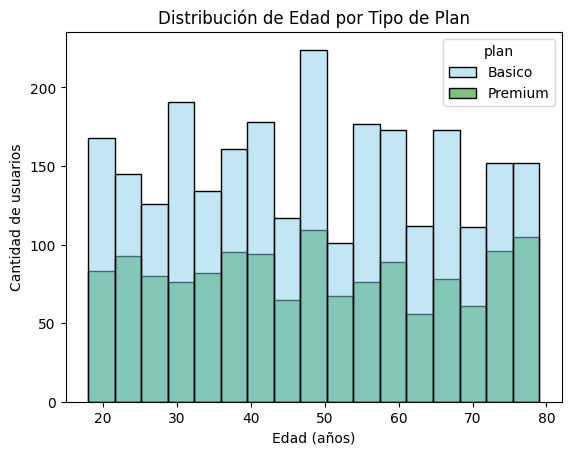

In [33]:
# Histograma para visualizar la edad (age)

# 1. EL TÍTULO
plt.title('Distribución de Edad por Tipo de Plan')

# 2. EL DIBUJO DEL GRÁFICO (El motor principal)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])

# 3. LAS ETIQUETAS DE LOS EJES
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de usuarios')

# 4. EL CIERRE
plt.show()


💡Insights: 


- Distribución uniforme y homogénea: Dentro del plan Premium y el plan Básico, la proporción de usuarios se mantiene relativamente constante en todas las edades (de 20 a 80 años). No existe algún patrón o preferencia generacional clara que distinga a un plan del otro.
Tipo de distribución: El gráfico presenta una distribución uniforme (o simétrica plana), ya que la cantidad de usuarios se distribuye de manera casi equivalente a lo largo de todo el eje de edad, sin mostrar un sesgo marcado hacia la derecha (jóvenes) ni hacia la izquierda (adultos mayores).



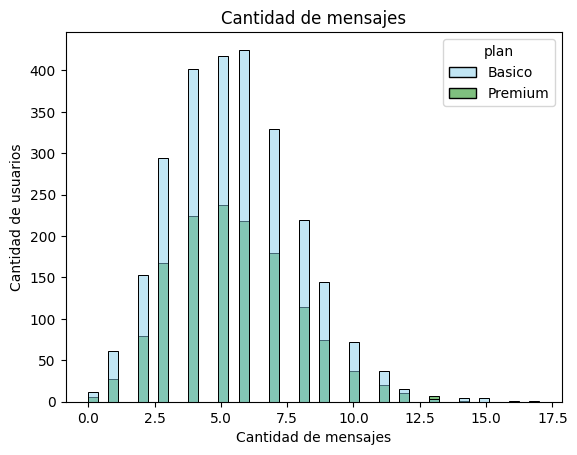

In [40]:
# Histograma para visualizar la cant_mensajes


# 1. EL TÍTULO
plt.title('Cantidad de mensajes')

# 2. EL DIBUJO DEL GRÁFICO (El motor principal)
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])

# 3. LAS ETIQUETAS DE LOS EJES
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')

# 4. EL CIERRE
plt.show()




💡Insights: 
Comportamiento de consumo similar: Los usuarios de los planes Básico y Premium tienden a enviar una cantidad similar de mensajes, concentrando su mayor uso entre los 4 y 6 mensajes. No existe algún patrón o diferencia clara en el volumen de mensajería que distinga el comportamiento de un plan frente al otro.
Tipo de distribución: El gráfico presenta una distribución sesgada a la derecha, ya que la gran mayoría de los usuarios se agrupa en los valores bajos y medios (entre 2.5 y 7.5 mensajes), mientras que la cantidad de usuarios disminuye notablemente hacia la derecha, generando una cola larga en los valores más altos.


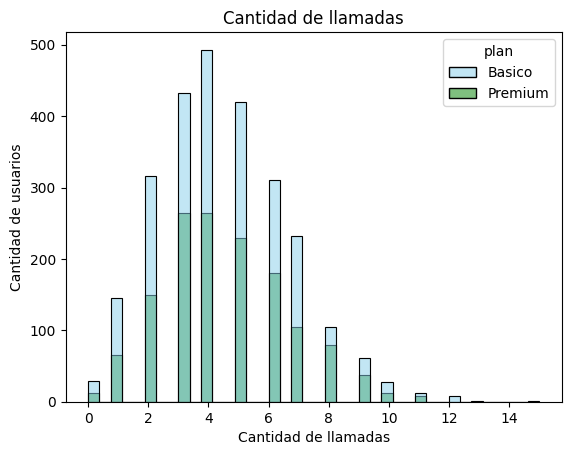

In [39]:

# Histograma para visualizar la cant_llamadas
# 1. EL TÍTULO
plt.title('Cantidad de llamadas')

# 2. EL DIBUJO DEL GRÁFICO (El motor principal)
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])

# 3. LAS ETIQUETAS DE LOS EJES
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')

# 4. EL CIERRE
plt.show()



💡Insights: 
• Comportamiento de llamadas similar: Los usuarios de los planes Básico y Premium tienden a hacer una cantidad muy similar de llamadas, alcanzando su punto máximo entre las 3 y 5 llamadas. Al igual que con los mensajes, no existe algún patrón o diferencia marcada que distinga el uso del servicio telefónico entre un plan y el otro.
• Tipo de distribución: El gráfico presenta una distribución sesgada a la derecha, debido a que la gran mayoría de los usuarios se concentra en valores bajos y medios (entre 2 y 6 llamadas), y la cantidad de usuarios va disminuyendo progresivamente hacia valores más altos, formando una cola alargada hacia el extremo derecho del eje.


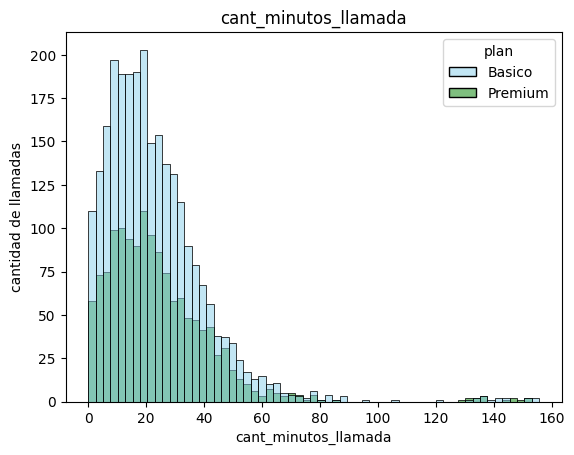

In [44]:
# Histograma para visualizar la cant_minutos_llamada

# Histograma para visualizar la cant_llamadas
# 1. EL TÍTULO
plt.title('cant_minutos_llamada')

# 2. EL DIBUJO DEL GRÁFICO (El motor principal)
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])

# 3. LAS ETIQUETAS DE LOS EJES
plt.xlabel('cant_minutos_llamada')
plt.ylabel('cantidad de llamadas')

# 4. EL CIERRE
plt.show()



💡Insights: 
• Duración de llamadas similar: Los usuarios de los planes Básico y Premium tienden a hablar una cantidad de minutos muy parecida por llamada, concentrando su mayor uso entre los 10 y 25 minutos. No existe algún patrón o diferencia notable en la duración de las llamadas que distinga el comportamiento de un plan frente al otro.
• Tipo de distribución: El gráfico presenta una distribución sesgada a la derecha, ya que la inmensa mayoría de los usuarios se agrupa en duraciones cortas y medianas (menos de 40 minutos), mientras que la frecuencia cae drásticamente hacia valores más altos, extendiendo una cola larga hacia el extremo derecho con la presencia de algunos valores atípicos (outliers) que superan los 120 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

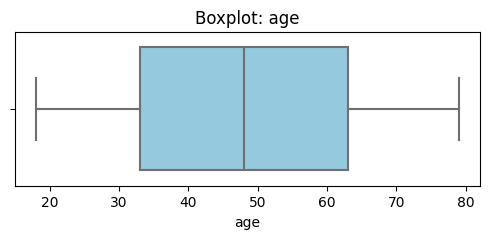

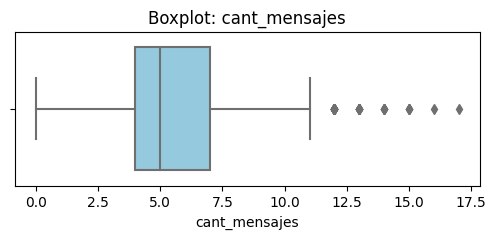

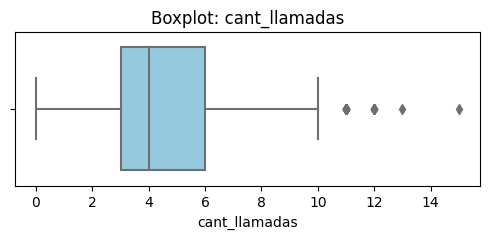

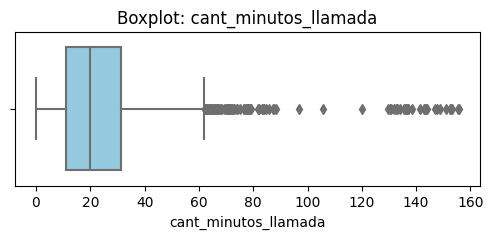

In [45]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 2))  
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
  El 50% de los usuarios se concentra de forma muy equilibrada entre los 33 y 63 años, teniendo una mediana de edad cercana a los 48 años. No existe algún outlier, lo que confirma que la base de clientes abarca un rango de edad real y completamente normal (de 20 a 80 años)."
- cant_mensajes:
  La mayoría de los usuarios se mantiene en un consumo bajo, donde el 50% central envía entre 4 y 7 mensajes. Sin embargo, existen outliers en el lado derecho, mostrando un grupo pequeño de clientes atípicos que superan los 11 mensajes y llegan hasta un máximo de 17.
- cant_llamadas:
  La mitad de los usuarios realiza entre 3 y 6 llamadas de forma regular. Al igual que con los mensajes, existen outliers únicamente en el lado derecho, identificando a usuarios que realizan un volumen inusual de llamadas (entre 11 y 15 llamadas).
- cant_minutos_llamada:
  El comportamiento estándar de los clientes es hacer llamadas cortas, acumulando la gran mayoría entre 10 y 30 minutos. No obstante, existe una gran cantidad de outliers severos a la derecha a partir de los 62 minutos, destacando un grupo crítico de usuarios 'heavy users' que llegan a hablar de forma extrema hasta casi 160 minutos.

In [49]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # 1. Obtenemos los percentiles 25 y 75 desde tu tabla 'users'
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    
    # 2. Calculamos la distancia de la caja (IQR)
    iqr = q3 - q1
    
    # 3. Calculamos la frontera del bigote derecho
    limite_superior = q3 + (1.5 * iqr)
    
    # 4. Mostramos el resultado en pantalla
    print(f"Variable: {col}")
    print(f"  -> El límite para detectar outliers es: {limite_superior:.2f}")
    print("-" * 50)



Variable: cant_mensajes
  -> El límite para detectar outliers es: 11.50
--------------------------------------------------
Variable: cant_llamadas
  -> El límite para detectar outliers es: 10.50
--------------------------------------------------
Variable: cant_minutos_llamada
  -> El límite para detectar outliers es: 61.86
--------------------------------------------------


In [50]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  Mantener: Enviar hasta 17 mensajes en un periodo es un comportamiento perfectamente normal, lógico y real para cualquier usuario de telefonía móvil
- cant_llamadas: mantener o no outliers, porqué?
  Mantener: Al igual que con los mensajes, un máximo de 15 llamadas no representa un error en el sistema ni un comportamiento descabellado; simplemente se trata de clientes que usan el teléfono un poco más que el promedio de la muestra.
- cant_minutos_llamada: mantener o no outliers, porqué?
  Es un valor alejado del promedio mas de dos horas y media de llamada de diferencia, el limite es  61.86 minutos, pero el valor máximo llega de forma extrema hasta 155.69 minutos. Lo mantendria al margen porque muestra un comportamiento del usuario, creando una lectura de comportamiento o una categoria especial de cliente lo que le da una lectura al análisis. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [51]:
# Crear columna grupo_uso
import numpy as np

# 1. Definimos las condiciones lógicas (usando los nombres reales de tus columnas)
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),   # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]

# 2. Definimos las etiquetas correspondientes a las condiciones de arriba
opciones = ['Bajo uso', 'Uso medio']

# 3. Creamos la nueva columna y asignamos 'Alto uso' por defecto para el resto de casos
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

# 4. Verificamos que se haya creado correctamente viendo las primeras filas
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [53]:
# Crear columna grupo_edad
# 1. Definimos las condiciones lógicas para la edad
condiciones_edad = [
    (user_profile['age'] < 30),  # Joven
    (user_profile['age'] < 60)   # Adulto
]

# 2. Definimos las etiquetas correspondientes
opciones_edad = ['Joven', 'Adulto']

# 3. Creamos la columna 'grupo_edad' asignando 'Adulto Mayor' por defecto al resto
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

# 4. Verificamos los resultados mostrando las primeras filas
user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [54]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

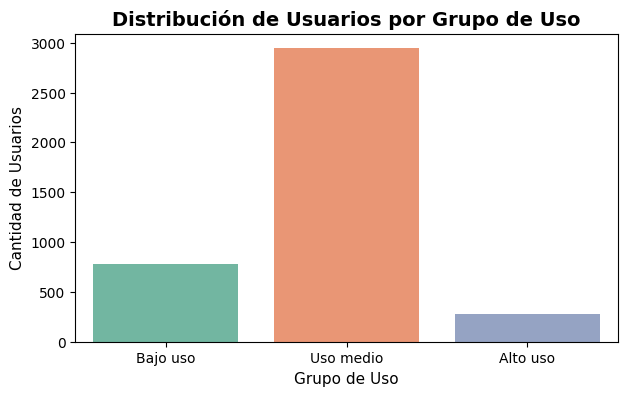

In [55]:
# Visualización de los segmentos por uso
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución por Grupo de Uso

plt.figure(figsize=(7, 4))
# Definimos un orden lógico para las barras
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']

sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso, palette='Set2')

# Título y etiquetas
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)

plt.show()




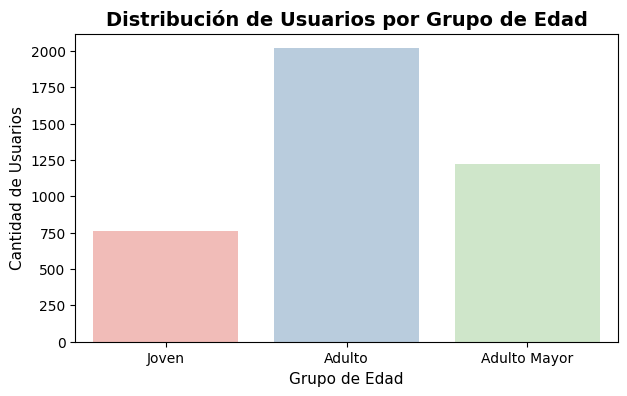

In [56]:
# Visualización de los segmentos por edad

plt.figure(figsize=(7, 4))
# Definimos un orden lógico para las barras
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']

sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad, palette='Pastel1')

# Título y etiquetas
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Qué encontramos en los datos y cómo lo resolvimos

Al revisar los datasets aparecieron algunos problemas de calidad. En la tabla de usuarios, 40 registros de la columna reg_date tenían año 2026, algo imposible porque el límite del proyecto es 2024, así que se trata de errores de captura. En la tabla de uso, 50 registros de la columna date estaban corruptos y los convertimos en nulos (NaN). Entre ambos casos suman menos del 0.1% de las casi 40,000 filas, por lo que los eliminamos con filtros y con .dropna(subset=['date']) sin que se alterara el panorama general.

También encontramos nulos que no son un error, sino parte de cómo funciona el sistema (tipo MAR). Hay 22,076 nulos en duración, que corresponden a mensajes de texto porque no acumulan minutos, y 17,896 nulos en longitud, que corresponden a llamadas de voz porque no tienen caracteres. Son vacíos que tienen sentido y no hay que corregirlos.

Quiénes son nuestros clientes

Por edad, los usuarios se reparten de forma bastante uniforme entre los 20 y los 80 años. La mediana es de 48 años y el 50% central se ubica entre los 33 y los 63. El grupo más grande es el de Adultos (30 a 59 años), con más de 2,000 usuarios, seguido por los Adultos Mayores, con unos 1,250, y los Jóvenes, con unos 750. Lo más importante aquí es que la edad no influye en el plan que se elige: las proporciones se mantienen iguales en todos los rangos, con 64.87% en el plan Básico y 35.12% en el Premium.

Por nivel de uso, el grupo de Uso medio domina por mucho, con cerca de 2,900 usuarios. Le siguen los de Bajo uso, con unos 800, y por último los de Alto uso, con unos 300. En general, el consumo se concentra en valores bajos: entre 4 y 6 mensajes, entre 3 y 5 llamadas y entre 10 y 25 minutos por interacción.

Dónde está el valor para ConnectaTel

En teoría, el cliente más valioso es el de Alto uso en plan Premium, porque es quien más consume y quien paga la tarifa más alta. Sin embargo, la mayor oportunidad está en otro lado: hay clientes de Alto uso que siguen en el plan Básico. Usan la red igual que un usuario Premium, pero pagan lo mínimo. Ese subgrupo es el objetivo número uno para campañas de migración de plan.

Los casos extremos y qué nos dicen

También detectamos comportamientos que se salen de lo normal en el extremo alto. En mensajes, la mayoría envía entre 4 y 7, pero hay casos que llegan hasta 17. En llamadas, la mitad central hace entre 3 y 6, con casos de hasta 15. En minutos por llamada, lo habitual está entre 10 y 30, pero aparece un volumen importante de valores atípicos desde los 61.86 minutos, con un máximo de 155.69.

Decidimos conservar estos valores porque no son errores, sino consumo real. Para el negocio, esto revela un nicho de "Heavy Users" que carga bastante los canales de voz, pero que también es el grupo más dependiente del servicio y con mayor potencial de facturación.

Qué recomendamos hacer

Como el consumo de los planes Básico y Premium se solapa casi por completo, la estructura actual de planes no está separando el comportamiento real de los clientes. Por eso proponemos tres acciones.

La primera es poner un tope al plan Básico, por ejemplo de 50 o 60 minutos mensuales. Al superarlo, se podría cobrar el minuto excedente o impulsar la migración automática al plan Premium.

La segunda es lanzar un "Plan Conectado / Pro", un Premium superior con minutos ilimitados o paquetes de voz de larga duración, pensado para ese grupo atípico que promedia llamadas de más de dos horas.

La tercera es cambiar el enfoque del marketing. Como la edad no influye en la elección del plan, no tiene sentido segmentar las campañas por rangos de edad. Lo más conveniente es comunicar según el perfil de uso, con mensajes distintos para los "Ahorradores" (bajo uso) y para los "Productivos" (alto uso).


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se encontraron 40 registros con fecha de registro en 2026 (fuera del límite válido de 2024) y 50 fechas de uso corruptas. En total son menos del 0.1% de las casi 40,000 filas, así que se eliminaron sin afectar los resultados.

Los nulos en duración (22,076) y en longitud (17,896) no son errores: corresponden a mensajes de texto, que no tienen minutos, y a llamadas de voz, que no tienen caracteres. Se mantienen tal como están.


🔍 **Segmentos por Edad**
La edad se distribuye de forma uniforme entre los 20 y 80 años, con una mediana de 48. El grupo más grande es el de Adultos (30 a 59 años), con más de 2,000 usuarios, seguido por Adultos Mayores (~1,250) y Jóvenes (~750).

La edad no influye en el plan elegido: en todos los rangos la proporción se mantiene en 65% Básico y 35% Premium.


📊 **Segmentos por Nivel de Uso**

Predomina el Uso medio (~2,900 usuarios), seguido por Bajo uso (~800) y Alto uso (~300). La mayoría consume poco: entre 4 y 6 mensajes, 3 y 5 llamadas, y 10 a 25 minutos por interacción.
Existe un grupo de usuarios intensivos ("Heavy Users"), con llamadas de hasta 155 minutos y casos de hasta 17 mensajes y 15 llamadas. Son consumos reales, por eso se conservaron en el análisis.


➡️ Esto sugiere que los planes actuales no reflejan cómo usan realmente el servicio los clientes. El consumo de Básico y Premium es casi idéntico, y hay usuarios de Alto uso pagando la tarifa mínima. Ahí está la principal oportunidad comercial: son los clientes con mayor potencial de migrar a Premium.


💡 **Recomendaciones**
Poner un tope de minutos al plan Básico (50 o 60 mensuales), con cobro por excedente o migración automática a Premium.
Lanzar un plan "Conectado / Pro" con minutos ilimitados o paquetes de voz de larga duración, dirigido a los Heavy Users.
Segmentar el marketing por perfil de uso y no por edad, con mensajes distintos para "Ahorradores" (bajo uso) y "Productivos" (alto uso).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`